In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [2]:
df = pd.read_csv("./xyz.csv")
df.head(5)

,Name,Attendance (%),Study Hours/Week,Previous Score,Extracurricular Activities,Final Score
0,Jane Smith,68.73,15.44,83.71,Low,72.58
1,Chris Jones,97.54,13.5,67.65,High,74.82
2,Emily Williams,86.60,15.46,71.73,Low,73.49
3,Anna Moore,79.93,5.06,67.09,High,62.87
4,Beth Taylor,57.80,13.9,50.74,High,56.62


In [3]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
df.head(5)

,name,attendance_(%),study_hours/week,previous_score,extracurricular_activities,final_score
0,Jane Smith,68.73,15.44,83.71,Low,72.58
1,Chris Jones,97.54,13.5,67.65,High,74.82
2,Emily Williams,86.60,15.46,71.73,Low,73.49
3,Anna Moore,79.93,5.06,67.09,High,62.87
4,Beth Taylor,57.80,13.9,50.74,High,56.62


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 736 entries, 0 to 735
Data columns (total 6 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   name                        736 non-null    object 
 1   attendance_(%)              736 non-null    float64
 2   study_hours/week            736 non-null    object 
 3   previous_score              736 non-null    float64
 4   extracurricular_activities  736 non-null    object 
 5   final_score                 736 non-null    float64
dtypes: float64(3), object(3)
memory usage: 34.6+ KB


In [5]:
print(df.isnull().sum())

name                          0
attendance_(%)                0
study_hours/week              0
previous_score                0
extracurricular_activities    0
final_score                   0
dtype: int64


In [6]:
label_encoder = LabelEncoder()
df['extracurricular_activities'] = label_encoder.fit_transform(df['extracurricular_activities'])
df.head(5)

,name,attendance_(%),study_hours/week,previous_score,extracurricular_activities,final_score
0,Jane Smith,68.73,15.44,83.71,1,72.58
1,Chris Jones,97.54,13.5,67.65,0,74.82
2,Emily Williams,86.60,15.46,71.73,1,73.49
3,Anna Moore,79.93,5.06,67.09,0,62.87
4,Beth Taylor,57.80,13.9,50.74,0,56.62


In [7]:
df.describe()

,attendance_(%),previous_score,extracurricular_activities,final_score
count,736.000000,736.000000,736.000000,736.000000
mean,72.074416,74.925408,1.199728,73.423668
std,12.827130,10.584747,0.816197,6.060941
min,50.280000,40.850000,0.000000,54.920000
25%,60.655000,68.620000,0.000000,67.580000
50%,68.020000,75.980000,1.000000,73.535000
75%,86.090000,82.760000,2.000000,77.580000
max,99.340000,94.450000,2.000000,88.720000


In [8]:
df.head()

,name,attendance_(%),study_hours/week,previous_score,extracurricular_activities,final_score
0,Jane Smith,68.73,15.44,83.71,1,72.58
1,Chris Jones,97.54,13.5,67.65,0,74.82
2,Emily Williams,86.60,15.46,71.73,1,73.49
3,Anna Moore,79.93,5.06,67.09,0,62.87
4,Beth Taylor,57.80,13.9,50.74,0,56.62


In [16]:
student = df.drop('name', axis=1)

In [17]:
print(student.dtypes)

attendance_(%)                float64
study_hours/week               object
previous_score                float64
extracurricular_activities      int64
final_score                   float64
dtype: object


<Axes: xlabel='previous_score', ylabel='final_score'>

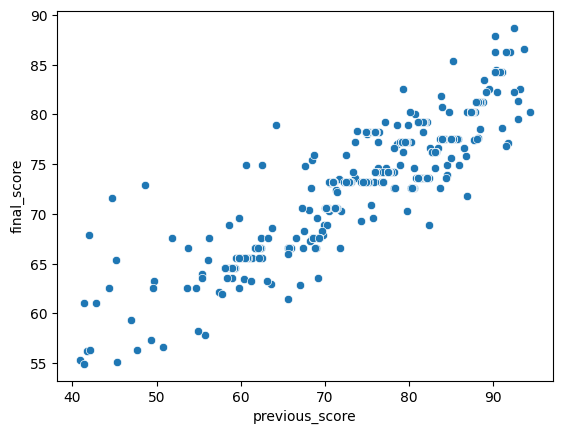

In [18]:
sns.scatterplot(x="previous_score",y="final_score",data=student)

The scatterplot between previous_score and final_score shows that they are not too much linearly realted to each other which means that the current performance of the students doesn't rely greatly on the previous performance.

In [19]:
corr_mat = student.corr()
sns.heatmap(corr_mat,annot=True)

ValueError: could not convert string to float: '13.ૅ'

From the analysis of heatmap, it was found that attendance and study_hours/week showed negative correlation which indicated that dtudents not attending the college study more than the students attending the college at their home. However, it's surprising to notice that study_hours and final_score had a negative correlation which might indicate that study_hours/week maynot be measured in a good way.